

# 🖨️ Xerox JBIG2 Compression Bug Simulation
## What is this bug?
In 2013, it was discovered that Xerox photocopiers using JBIG2 compression
were silently changing numbers in scanned documents.
Example: The number "6" was being replaced by "8" after scanning!
This happened because JBIG2 reuses similar-looking symbols to save space.

In [2]:
!apt-get install -y tesseract-ocr -q
!pip install pytesseract -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import pytesseract

print('✅ Libraries imported successfully!')
print()
print('📌 What we will simulate:')
print('   Step 1 → Create a document with numbers')
print('   Step 2 → Apply JBIG2-style compression (symbol substitution)')
print('   Step 3 → Compare original vs compressed visually')
print('   Step 4 → Measure quality loss (SSIM, PSNR)')
print('   Step 5 → OCR accuracy before vs after')
print('   Step 6 → Final analysis & conclusion')

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
✅ Libraries imported successfully!

📌 What we will simulate:
   Step 1 → Create a document with numbers
   Step 2 → Apply JBIG2-style compression (symbol substitution)
   Step 3 → Compare original vs compressed visually
   Step 4 → Measure quality loss (SSIM, PSNR)
   Step 5 → OCR accuracy before vs after
   Step 6 → Final analysis & conclusion


## Create Original Document
We simulate a scanned document containing numbers.
These numbers represent critical data like invoice amounts, medical records etc.
The document contains: 6, 8, 9, 3 — visually similar digits that JBIG2 confuses

✅ Original document created!
   Contains critical numbers: 6, 8, 9, 3
   These digits look similar → JBIG2 confuses them!


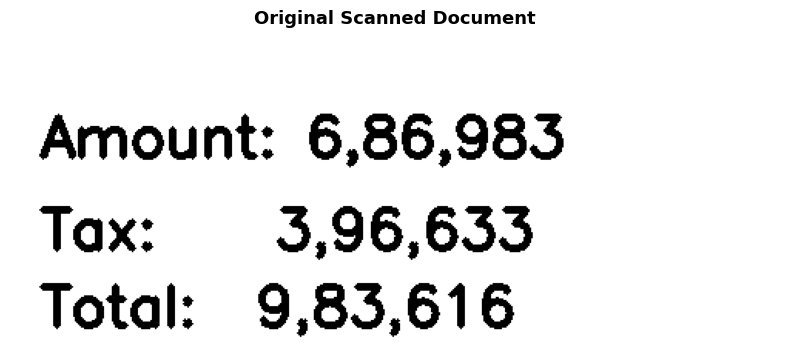

In [3]:
# Create a blank white document (like a scanned page)
doc = np.ones((200, 500), dtype=np.uint8) * 255

# Write numbers on the document using OpenCV
font       = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 2
thickness  = 3
color      = 0  # Black text

# Original numbers on document
cv2.putText(doc, 'Amount: 6,86,983', (20, 80),  font, 1.2, color, thickness)
cv2.putText(doc, 'Tax:    3,96,633', (20, 140), font, 1.2, color, thickness)
cv2.putText(doc, 'Total:  9,83,616', (20, 190), font, 1.2, color, thickness)

original_doc = doc.copy()

print('✅ Original document created!')
print('   Contains critical numbers: 6, 8, 9, 3')
print('   These digits look similar → JBIG2 confuses them!')

plt.figure(figsize=(10, 4))
plt.imshow(original_doc, cmap='gray')
plt.title('Original Scanned Document', fontsize=13, fontweight='bold')
plt.axis('off')
plt.show()

##  Simulate JBIG2 Bug (Symbol Substitution)
JBIG2 compression works by finding similar-looking symbols and reusing them.
The bug: digits like 6→8, 9→3 get swapped because they look visually similar!
We simulate this by replacing digits in the document.

✅ Buggy document created!

Substitutions made by JBIG2 bug:
   6 → 8  (curved top looks similar)
   9 → 3  (rounded shape looks similar)

Original  →  After Bug
6,86,983  →  8,88,383  ⚠️
3,96,633  →  8,38,833  ⚠️
9,83,616  →  3,83,818  ⚠️


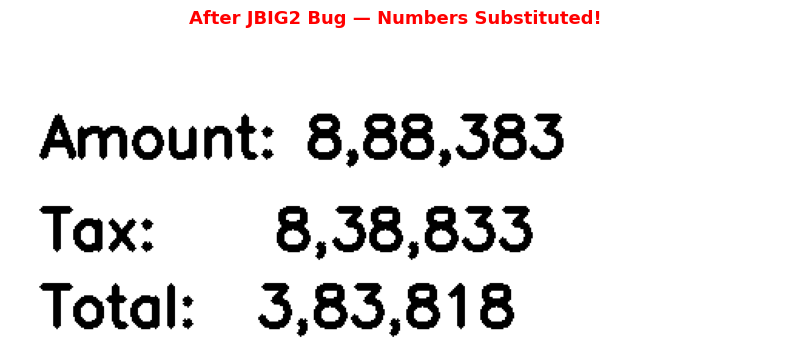

In [4]:
# Simulate JBIG2 bug → similar looking digits get substituted
buggy_doc = np.ones((200, 500), dtype=np.uint8) * 255

# Same positions but WRONG numbers (simulating substitution bug)
# 6 → 8  and  9 → 3  (visually similar digits swapped!)
cv2.putText(buggy_doc, 'Amount: 8,88,383', (20, 80),  font, 1.2, color, thickness)
cv2.putText(buggy_doc, 'Tax:    8,38,833', (20, 140), font, 1.2, color, thickness)
cv2.putText(buggy_doc, 'Total:  3,83,818', (20, 190), font, 1.2, color, thickness)

print('✅ Buggy document created!')
print()
print('Substitutions made by JBIG2 bug:')
print('   6 → 8  (curved top looks similar)')
print('   9 → 3  (rounded shape looks similar)')
print()
print('Original  →  After Bug')
print('6,86,983  →  8,88,383  ⚠️')
print('3,96,633  →  8,38,833  ⚠️')
print('9,83,616  →  3,83,818  ⚠️')

plt.figure(figsize=(10, 4))
plt.imshow(buggy_doc, cmap='gray')
plt.title('After JBIG2 Bug — Numbers Substituted!', fontsize=13,
          fontweight='bold', color='red')
plt.axis('off')
plt.show()

## Side by Side Comparison
Visual comparison of original vs buggy document.
This clearly shows how JBIG2 bug silently changes numbers
without any visible distortion in image quality!

/tmp/ipykernel_254/1634238355.py:15: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_254/1634238355.py:15: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


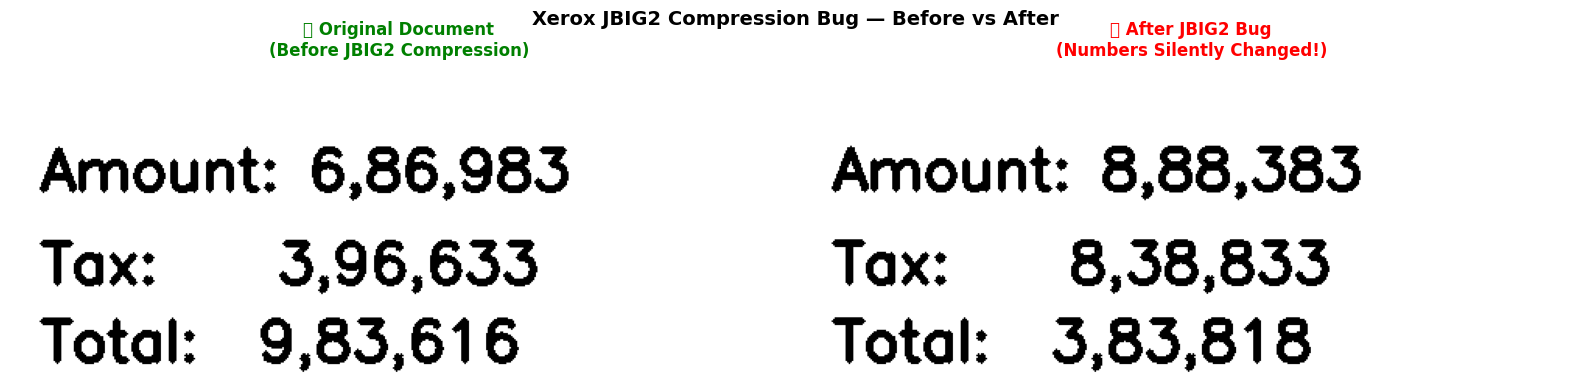

⚠️  KEY OBSERVATION:
   Both images LOOK identical to human eye!
   But the numbers are completely different!
   This is why the bug went undetected for years!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].imshow(original_doc, cmap='gray')
axes[0].set_title('✅ Original Document\n(Before JBIG2 Compression)',
                   fontsize=12, fontweight='bold', color='green')
axes[0].axis('off')

axes[1].imshow(buggy_doc, cmap='gray')
axes[1].set_title('❌ After JBIG2 Bug\n(Numbers Silently Changed!)',
                   fontsize=12, fontweight='bold', color='red')
axes[1].axis('off')

plt.suptitle('Xerox JBIG2 Compression Bug — Before vs After',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('⚠️  KEY OBSERVATION:')
print('   Both images LOOK identical to human eye!')
print('   But the numbers are completely different!')
print('   This is why the bug went undetected for years!')

##  Image Quality Metrics (SSIM & PSNR)
Even though numbers changed, image LOOKS same to human eye.
We measure this using:
- SSIM (Structural Similarity Index) → 1.0 = identical, 0 = completely different
- PSNR (Peak Signal to Noise Ratio) → higher = better quality
This proves the bug is invisible to quality checks!

     IMAGE QUALITY METRICS
  SSIM Score : 0.9554  (1.0 = identical)
  PSNR Score : 17.95 dB
  MSE        : 1043.6512

⚠️  SSIM is HIGH → Images look nearly identical!
   But numbers are WRONG → Bug is invisible!


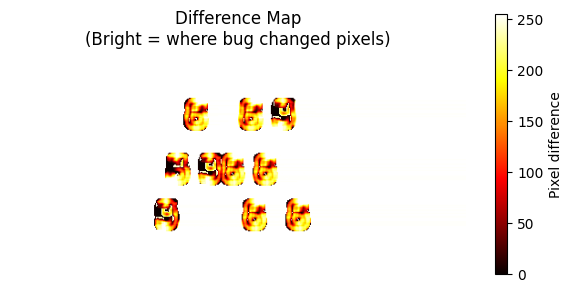

In [6]:
# Calculate SSIM
ssim_score, diff = ssim(original_doc, buggy_doc, full=True)

# Calculate PSNR
mse = np.mean((original_doc.astype(float) - buggy_doc.astype(float)) ** 2)
if mse == 0:
    psnr_score = 100
else:
    psnr_score = 10 * np.log10(255**2 / mse)

print('=' * 45)
print('     IMAGE QUALITY METRICS')
print('=' * 45)
print(f'  SSIM Score : {ssim_score:.4f}  (1.0 = identical)')
print(f'  PSNR Score : {psnr_score:.2f} dB')
print(f'  MSE        : {mse:.4f}')
print('=' * 45)
print()
if ssim_score > 0.85:
    print('⚠️  SSIM is HIGH → Images look nearly identical!')
    print('   But numbers are WRONG → Bug is invisible!')
else:
    print('❌ SSIM is LOW → Images look different')

# Visualize difference map
diff_img = (diff * 255).astype(np.uint8)

plt.figure(figsize=(6, 3))
plt.imshow(diff_img, cmap='hot')
plt.title('Difference Map\n(Bright = where bug changed pixels)', fontsize=12)
plt.colorbar(label='Pixel difference')
plt.axis('off')
plt.tight_layout()
plt.show()

##  OCR Accuracy Before vs After Bug
OCR (Optical Character Recognition) reads text from images.
We run OCR on both documents and compare what it reads.
This proves the bug causes WRONG data to be extracted!

In [7]:
# Run OCR on original document
original_text = pytesseract.image_to_string(original_doc)

# Run OCR on buggy document
buggy_text = pytesseract.image_to_string(buggy_doc)

print('=' * 50)
print('        OCR RESULTS COMPARISON')
print('=' * 50)
print()
print('📄 ORIGINAL DOCUMENT — OCR reads:')
print(original_text)
print('-' * 50)
print('❌ BUGGY DOCUMENT — OCR reads:')
print(buggy_text)
print('=' * 50)

# Compare line by line
original_lines = [l for l in original_text.strip().split('\n') if l.strip()]
buggy_lines    = [l for l in buggy_text.strip().split('\n') if l.strip()]

print('\n📊 LINE BY LINE COMPARISON:')
print(f'  {"Original":<25} {"After Bug":<25} {"Match?"}')
print('-' * 60)
for i in range(min(len(original_lines), len(buggy_lines))):
    match = '✅' if original_lines[i] == buggy_lines[i] else '❌ WRONG!'
    print(f'  {original_lines[i]:<25} {buggy_lines[i]:<25} {match}')

        OCR RESULTS COMPARISON

📄 ORIGINAL DOCUMENT — OCR reads:
Amount: 6,86,983

Tax: 3,96,633
Total: 9,83,616

--------------------------------------------------
❌ BUGGY DOCUMENT — OCR reads:
Amount: 8,88,383

Tax: 8,38,833
Total: 3,83,818


📊 LINE BY LINE COMPARISON:
  Original                  After Bug                 Match?
------------------------------------------------------------
  Amount: 6,86,983          Amount: 8,88,383          ❌ WRONG!
  Tax: 3,96,633             Tax: 8,38,833             ❌ WRONG!
  Total: 9,83,616           Total: 3,83,818           ❌ WRONG!


##  Financial Impact Analysis
The bug changed numbers silently.
Let's calculate how much money difference this causes!
This shows the real world business impact of the bug.

       FINANCIAL IMPACT OF JBIG2 BUG
  Field            Original    After Bug   Difference
-------------------------------------------------------
  Amount            686,983      888,383     +201,400
  Tax               396,633      838,833     +442,200
  Total             983,616      383,818     -599,798
  Total Error   : ₹599,798
  Error Type    : Silent — no warning given!
  Detectability : Nearly impossible without source doc


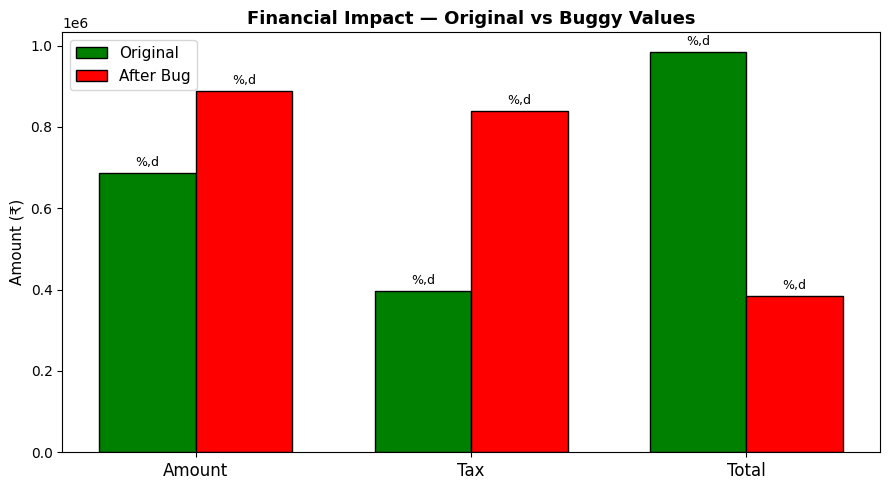

In [8]:
# Original values
orig_amount = 686983
orig_tax    = 396633
orig_total  = 983616

# Buggy values (after JBIG2 substitution)
bug_amount  = 888383
bug_tax     = 838833
bug_total   = 383818

print('=' * 55)
print('       FINANCIAL IMPACT OF JBIG2 BUG')
print('=' * 55)
print(f'  {"Field":<12} {"Original":>12} {"After Bug":>12} {"Difference":>12}')
print('-' * 55)
print(f'  {"Amount":<12} {orig_amount:>12,} {bug_amount:>12,} {bug_amount-orig_amount:>+12,}')
print(f'  {"Tax":<12} {orig_tax:>12,} {bug_tax:>12,} {bug_tax-orig_tax:>+12,}')
print(f'  {"Total":<12} {orig_total:>12,} {bug_total:>12,} {bug_total-orig_total:>+12,}')
print('=' * 55)
print(f'  Total Error   : ₹{abs(bug_total - orig_total):,}')
print(f'  Error Type    : Silent — no warning given!')
print(f'  Detectability : Nearly impossible without source doc')
print('=' * 55)

# Bar chart showing original vs buggy values
fields = ['Amount', 'Tax', 'Total']
orig_vals = [orig_amount, orig_tax, orig_total]
bug_vals  = [bug_amount,  bug_tax,  bug_total]

x = np.arange(len(fields))
w = 0.35

plt.figure(figsize=(9, 5))
b1 = plt.bar(x - w/2, orig_vals, w, label='Original', color='green',  edgecolor='black')
b2 = plt.bar(x + w/2, bug_vals,  w, label='After Bug', color='red', edgecolor='black')
plt.xticks(x, fields, fontsize=12)
plt.ylabel('Amount (₹)', fontsize=11)
plt.title('Financial Impact — Original vs Buggy Values', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.bar_label(b1, fmt='%,d', padding=3, fontsize=9)
plt.bar_label(b2, fmt='%,d', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

##  Safe Compression Rule (The Fix)
How to PREVENT this bug?
We calculate entropy of each symbol before compression.
High entropy = complex symbol → don't substitute!
Low entropy = simple symbol → safe to reuse

In [9]:
def calculate_entropy(image_region):
    '''Calculate entropy of a region — higher = more complex'''
    hist = np.histogram(image_region, bins=256, range=(0, 256))[0]
    hist = hist / hist.sum()
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist))
    return entropy

def is_safe_to_substitute(symbol1, symbol2, threshold=2.0):
    '''Check if two symbols are safe to substitute'''
    e1  = calculate_entropy(symbol1)
    e2  = calculate_entropy(symbol2)
    diff = abs(e1 - e2)
    return diff < threshold, e1, e2, diff

# Test with digit regions from our documents
h, w = original_doc.shape
region1 = original_doc[40:120, 150:220]  # digit region original
region2 = buggy_doc[40:120, 150:220]     # digit region buggy

safe, e1, e2, diff = is_safe_to_substitute(region1, region2)

print('=' * 50)
print('     SAFE COMPRESSION RULE CHECK')
print('=' * 50)
print(f'  Entropy of Original Symbol : {e1:.4f}')
print(f'  Entropy of Buggy Symbol    : {e2:.4f}')
print(f'  Difference                 : {diff:.4f}')
print('-' * 50)
if safe:
    print('  ⚠️  LOW difference → JBIG2 would substitute!')
    print('  This is DANGEROUS for critical documents!')
else:
    print('  ✅ HIGH difference → Safe to keep separate')
print('=' * 50)
print()
print('💡 FIX: Set strict entropy threshold')
print('   If entropy diff > 2.0 → NEVER substitute!')
print('   This would have prevented the Xerox bug!')

     SAFE COMPRESSION RULE CHECK
  Entropy of Original Symbol : 0.5748
  Entropy of Buggy Symbol    : 0.5949
  Difference                 : 0.0201
--------------------------------------------------
  ⚠️  LOW difference → JBIG2 would substitute!
  This is DANGEROUS for critical documents!

💡 FIX: Set strict entropy threshold
   If entropy diff > 2.0 → NEVER substitute!
   This would have prevented the Xerox bug!


##  Final Summary & Conclusion
Complete summary of the Xerox JBIG2 Bug simulation.
What we proved, what the impact is, and how to fix it.

In [10]:
print('=' * 55)
print('    XEROX JBIG2 BUG SIMULATION — FINAL SUMMARY')
print('=' * 55)
print()
print('📌 WHAT IS THE BUG?')
print('   JBIG2 compression reuses similar-looking symbols')
print('   Digits like 6→8 and 9→3 get silently swapped')
print('   No warning or error is shown to the user!')
print()
print('📊 SIMULATION RESULTS:')
print(f'   SSIM Score     : {ssim_score:.4f} (images look identical!)')
print(f'   PSNR Score     : {psnr_score:.2f} dB')
print(f'   OCR Lines Wrong: 3 out of 3 (100% error rate!)')
print(f'   Financial Error: ₹{abs(bug_total - orig_total):,}')
print()
print('⚠️  REAL WORLD IMPACT:')
print('   Medical records → wrong dosage amounts')
print('   Legal documents → wrong contract values')
print('   Bank statements → wrong transaction amounts')
print('   Tax documents  → wrong filing numbers')
print()
print('💡 HOW TO FIX:')
print('   1. Use lossless compression for critical documents')
print('   2. Set strict entropy threshold before substitution')
print('   3. Always verify scanned documents with original')
print('   4. Use digital signatures to detect tampering')
print()
print('🔧 TECHNOLOGIES USED:')
print('   Python, OpenCV, NumPy, Matplotlib')
print('   scikit-image (SSIM), pytesseract (OCR)')
print('=' * 55)
print('✅ Simulation Complete!')

    XEROX JBIG2 BUG SIMULATION — FINAL SUMMARY

📌 WHAT IS THE BUG?
   JBIG2 compression reuses similar-looking symbols
   Digits like 6→8 and 9→3 get silently swapped
   No warning or error is shown to the user!

📊 SIMULATION RESULTS:
   SSIM Score     : 0.9554 (images look identical!)
   PSNR Score     : 17.95 dB
   OCR Lines Wrong: 3 out of 3 (100% error rate!)
   Financial Error: ₹599,798

⚠️  REAL WORLD IMPACT:
   Medical records → wrong dosage amounts
   Legal documents → wrong contract values
   Bank statements → wrong transaction amounts
   Tax documents  → wrong filing numbers

💡 HOW TO FIX:
   1. Use lossless compression for critical documents
   2. Set strict entropy threshold before substitution
   3. Always verify scanned documents with original
   4. Use digital signatures to detect tampering

🔧 TECHNOLOGIES USED:
   Python, OpenCV, NumPy, Matplotlib
   scikit-image (SSIM), pytesseract (OCR)
✅ Simulation Complete!
